# Chapter 3: Tangent Vectors

## Source Span

**Book.** `Introduction to Smooth Manifolds`  
**Chapter.** Chapter 3, `Tangent Vectors`  
**Printed pages.** `50-76` in the course `source_map.json`  
**PDF extraction window used for inspection.** physical PDF pages `68-94`, because printed page `50` begins on PDF page `68` in this file.

This notebook uses the source for structure, terminology, theorem orientation, and coverage only. The prose, examples, diagrams, computations, and checks below are original teaching material. No textbook page images, figure crops, exercise text, or copied passages are used.

## Chapter Goal

Build the tangent space from three mutually checking viewpoints:

- an attached arrow acts on functions as a derivation;
- a smooth map pushes tangent vectors forward by the differential;
- coordinates make the formulas computable while also revealing what changes when the chart changes.

By the end, the tangent bundle should feel less like a formal disjoint union and more like a charted space whose points are "base point plus velocity data." The final checks make the main invariants executable: product rule, coordinate-basis recovery, Jacobian pushforward, basis-change law, tangent-bundle projection, curve velocity, and functorial composition.


## Visual Storyboard

| Step | Concept | Representation | Artifact | Inspection target | Check |
| --- | --- | --- | --- | --- | --- |
| 1 | Derivations in Euclidean space | attached arrow plus contours | `figures/derivations-as-attached-arrows.png` | the same vector is both an arrow at `a` and an operator on functions | product rule and coordinate recovery |
| 2 | Coordinate bases on a manifold | sphere patch with coordinate tangent vectors | `figures/coordinate-basis-on-sphere.png` | partial derivatives of a chart land in the tangent plane | basis vectors are orthogonal to the normal and have positive Gram determinant |
| 3 | Differentials and Jacobians | domain curve, codomain curve, and pushed arrow | `figures/differential-jacobian-pushforward.png` | the Jacobian is the coordinate matrix of `dF_p` | velocity of `F o gamma` equals `J_F(p) gamma'(0)` |
| 4 | Basis-change laws | polar and Cartesian bases at one point | `figures/basis-change-polar-law.png` | vector components transform by the transition Jacobian, not by copying coefficients | correct transform has zero residual; polar chart fails at `r=0` |
| 5 | Tangent bundle projection | Plotly local model of `TS^1` as base plus fiber coordinate | `html/tangent-bundle-projection-local-model.html` | `pi: TM -> M` forgets velocity while each fiber keeps all velocities at one base point | projection, zero section, and fiber-coordinate checks |
| 6 | Curve velocities and boundary endpoints | half-plane boundary with one-sided curves | `figures/curve-velocities-boundary-modes.png` | every boundary tangent vector can be realized if endpoint curves are allowed | two-sided curves force zero normal velocity |
| 7 | Functoriality | commutative dependency diagram plus exact chain-rule computation | `figures/pushforward-functoriality-diagram.png` | `T` sends maps to differentials and preserves composition | `d(G o F)_p = dG_{F(p)} o dF_p` |
| 8 | Applied lab | polar radius sweep | `figures/polar-chart-failure-sweep.png` | the naive "same components in every chart" rule breaks; the true law degenerates at singular charts | residual table and determinant sweep |


## Library Routing

| Concept | Library route | Why this route fits | Fallback |
| --- | --- | --- | --- |
| derivations, coordinate formulas, and chain rules | `SymPy` | exact symbolic derivatives expose the product rule, Jacobian chain rule, and coordinate component laws without numerical guesswork | small hand-computed formulas |
| Euclidean arrows, chart bases, boundary curves, and failure sweeps | `Matplotlib` | static labeled diagrams are enough for attached vectors, local bases, and half-plane endpoint behavior | saved SVG/PNG from the same data |
| tangent-bundle projection | `Plotly` | a 3D local bundle model benefits from rotation: base point and fiber coordinate are easier to inspect interactively | static Matplotlib 3D snapshot |
| functorial dependency | `NetworkX` | the category-theoretic claims are graph-like: objects, maps, tangent spaces, and composition checks | hand-drawn commutative diagram |
| invariant and artifact reports | `json` / `csv` via course helpers | keeps each visual paired with a reproducible check under the chapter artifact tree | notebook-only assertions |


In [1]:
from pathlib import Path
import json
import math
import sys

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import plotly.graph_objects as go
import sympy as sp
from IPython.display import HTML, Markdown, display


def locate_book_root() -> Path:
    search = []
    for base in [Path.cwd(), *Path.cwd().parents]:
        search.extend([base, base / "Introduction-to-Smooth-Manifolds"])
    for candidate in search:
        if (candidate / "AGENTS.md").exists() and (candidate / "source_map.json").exists():
            return candidate.resolve()
    raise RuntimeError("Could not locate Introduction-to-Smooth-Manifolds course root")


BOOK_ROOT = locate_book_root()
if str(BOOK_ROOT) not in sys.path:
    sys.path.insert(0, str(BOOK_ROOT))

from utils.artifacts import (
    assert_artifacts,
    chapter_artifact_root,
    display_artifact,
    save_csv,
    save_json,
    save_matplotlib,
    save_plotly_html,
)

UNIT_KEY = "chapter-03-tangent-vectors"
UNIT_TITLE = "Tangent Vectors"
ARTIFACT_ROOT = chapter_artifact_root(UNIT_KEY, BOOK_ROOT)
FIGURES = ARTIFACT_ROOT / "figures"
HTML_DIR = ARTIFACT_ROOT / "html"
CHECKS = ARTIFACT_ROOT / "checks"
TABLES = ARTIFACT_ROOT / "tables"

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.grid": True,
    "grid.alpha": 0.25,
    "font.size": 10,
})

tracked_paths: list[Path] = []
check_results: dict[str, bool] = {}


def track(path: Path, kind: str, concept: str) -> Path:
    path = Path(path)
    tracked_paths.append(path)
    return path


def artifact_row(path: Path, kind: str, concept: str) -> dict[str, str | int]:
    path = Path(path)
    return {
        "relative_path": path.relative_to(ARTIFACT_ROOT).as_posix(),
        "kind": kind,
        "concept": concept,
        "bytes": path.stat().st_size if path.exists() else 0,
    }


def show(path: Path, *, width: int = 760, height: int = 520) -> None:
    path = Path(path)
    try:
        display_path = path.relative_to(Path.cwd())
    except ValueError:
        display_path = path
    display_artifact(display_path, width=width, height=height)


routing_rows = [
    {
        "concept": "derivations and coordinate recovery",
        "representation": "symbolic derivatives plus attached-arrow plot",
        "library": "SymPy, Matplotlib",
        "why": "the product rule is algebraic, while the base point attachment is visual",
        "artifact": "figures/derivations-as-attached-arrows.png",
    },
    {
        "concept": "coordinate bases on manifolds",
        "representation": "parameterized sphere patch and tangent basis",
        "library": "NumPy, Matplotlib",
        "why": "coordinate partials can be inspected as actual tangent-plane arrows",
        "artifact": "figures/coordinate-basis-on-sphere.png",
    },
    {
        "concept": "differential and Jacobian",
        "representation": "curve velocity before and after a map",
        "library": "SymPy, Matplotlib",
        "why": "the chain rule becomes a visible pushed vector plus an exact residual",
        "artifact": "figures/differential-jacobian-pushforward.png",
    },
    {
        "concept": "tangent bundle projection",
        "representation": "interactive base circle with vertical fibers",
        "library": "Plotly",
        "why": "rotating the local model separates base point from velocity coordinate",
        "artifact": "html/tangent-bundle-projection-local-model.html",
    },
    {
        "concept": "functoriality",
        "representation": "commutative diagram and exact matrix check",
        "library": "NetworkX, SymPy",
        "why": "the category claim is about preserving identities and composition",
        "artifact": "figures/pushforward-functoriality-diagram.png",
    },
]
routing_path = track(
    save_csv(routing_rows, TABLES / "tangent-vectors-library-routing.csv"),
    "table",
    "library routing",
)
display(Markdown("Setup complete. Library routing saved as `tables/tangent-vectors-library-routing.csv`."))


Setup complete. Library routing saved as `tables/tangent-vectors-library-routing.csv`.

## Translation Guide

The chapter moves between several languages. The table below is the working dictionary for the notebook.

| Book language | Computational language used here | What to inspect |
| --- | --- | --- |
| geometric tangent vector at `a` | pair `(a, v)` drawn as an attached arrow | changing `a` changes where the operator evaluates functions |
| derivation at a point | linear rule `D_v(f) = sum v_i partial_i f(a)` | it kills constants and satisfies the product rule |
| coordinate vector `partial/partial x_i |_p` | preimage under the chart differential of a Euclidean basis vector | a coordinate basis depends on the whole chart |
| differential `dF_p` | Jacobian of a coordinate representative, with domain and codomain bases specified | the matrix changes with coordinates, the linear map does not |
| tangent bundle `TM` | points `(p, velocity coordinates)` with projection `pi(p,v)=p` | locally product-like, not automatically a global product |
| velocity of a curve | derivation obtained by differentiating `f(gamma(t))` | velocity can compute `dF_p(v)` through a composite curve |
| tangent functor | assignment `M -> TM` and `F -> dF` | identities and compositions are preserved |


## Derivations: Attached Arrows Acting on Functions

A tangent vector in `R^n` can be drawn as an arrow attached to a base point, but the manifold definition needs a form that does not mention an ambient space. The replacement is: a vector is a linear operator on smooth functions satisfying the product rule at the base point.

The figure uses a single vector at a point in the plane. The contours remind us that the vector does not move the point through space by itself; it differentiates functions at the point. The JSON check records the product rule and the recovery of the vector components from its action on coordinate functions.


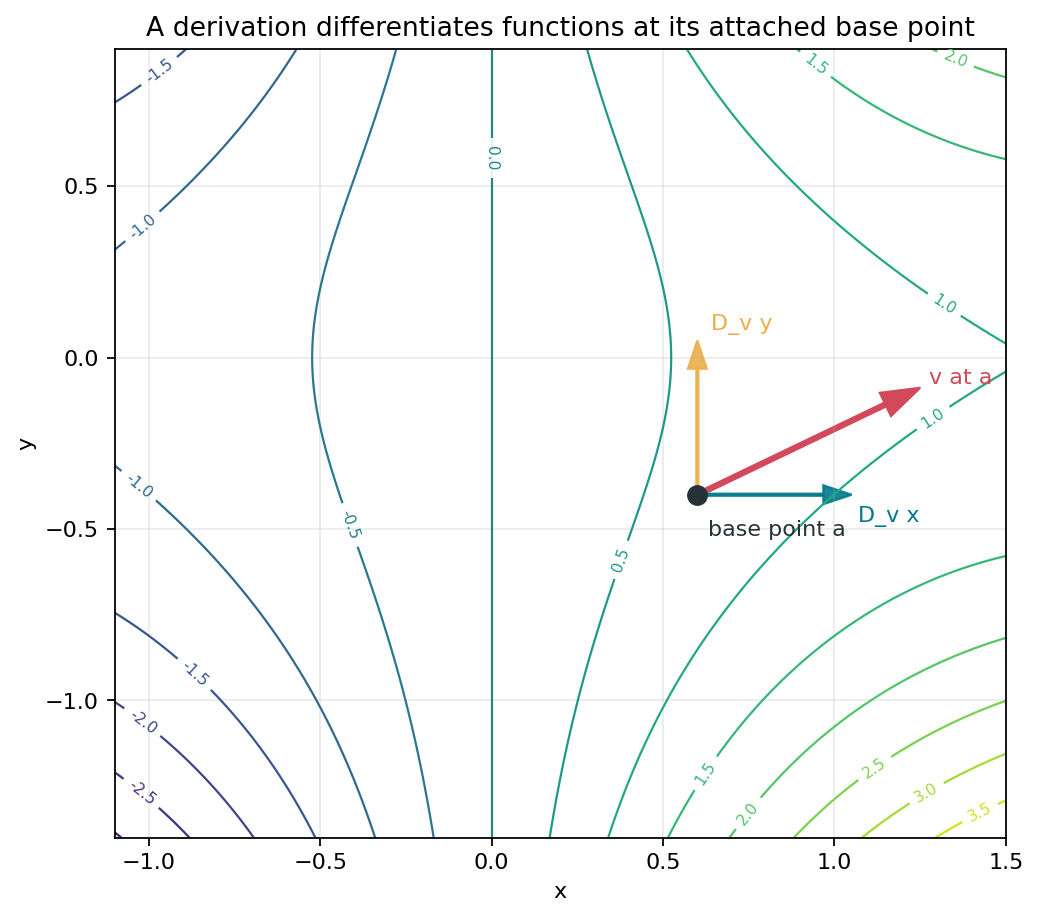

`D_v(f g) - f(a)D_v(g) - g(a)D_v(f) = 0`

In [2]:
x, y = sp.symbols("x y", real=True)
base = {x: sp.Rational(3, 5), y: -sp.Rational(2, 5)}
v_components = sp.Matrix([sp.Rational(5, 4), sp.Rational(3, 5)])
variables = (x, y)


def D(expr: sp.Expr) -> sp.Expr:
    return sp.simplify(
        sum(v_components[i] * sp.diff(expr, variables[i]) for i in range(2)).subs(base)
    )


f = sp.sin(x) + x * y**2
g = sp.exp(y) + x**2
product_residual = sp.simplify(D(f * g) - f.subs(base) * D(g) - g.subs(base) * D(f))
coordinate_recovery = [sp.simplify(D(var)) for var in variables]
constant_check = sp.simplify(D(sp.Integer(7)))

xx = np.linspace(-1.1, 1.5, 160)
yy = np.linspace(-1.4, 0.9, 160)
X, Y = np.meshgrid(xx, yy)
F = np.sin(X) + X * Y**2

fig, ax = plt.subplots(figsize=(7.4, 6.4))
levels = ax.contour(X, Y, F, levels=15, cmap="viridis", linewidths=1.0)
ax.clabel(levels, inline=True, fontsize=7, fmt="%.1f")
a_np = np.array([float(base[x]), float(base[y])])
v_np = np.array([float(v_components[0]), float(v_components[1])])
ax.scatter([a_np[0]], [a_np[1]], s=70, color="#263238", zorder=5)
ax.arrow(a_np[0], a_np[1], 0.52 * v_np[0], 0.52 * v_np[1],
         width=0.012, head_width=0.075, length_includes_head=True, color="#d1495b")
ax.arrow(a_np[0], a_np[1], 0.45, 0, width=0.006, head_width=0.055,
         length_includes_head=True, color="#00798c", alpha=0.9)
ax.arrow(a_np[0], a_np[1], 0, 0.45, width=0.006, head_width=0.055,
         length_includes_head=True, color="#edae49", alpha=0.9)
ax.text(a_np[0] + 0.03, a_np[1] - 0.12, "base point a", color="#263238")
ax.text(a_np[0] + 0.54 * v_np[0], a_np[1] + 0.54 * v_np[1], "v at a", color="#d1495b")
ax.text(a_np[0] + 0.47, a_np[1] - 0.08, "D_v x", color="#00798c")
ax.text(a_np[0] + 0.04, a_np[1] + 0.48, "D_v y", color="#edae49")
ax.set_aspect("equal", adjustable="box")
ax.set_title("A derivation differentiates functions at its attached base point")
ax.set_xlabel("x")
ax.set_ylabel("y")
derivation_fig = track(
    save_matplotlib(fig, FIGURES / "derivations-as-attached-arrows.png"),
    "figure",
    "derivations as attached arrows",
)
plt.close(fig)

derivation_check = {
    "base_point": [str(base[x]), str(base[y])],
    "components": [str(c) for c in v_components],
    "D_of_coordinate_functions": [str(c) for c in coordinate_recovery],
    "D_of_constant_7": str(constant_check),
    "product_rule_residual": str(product_residual),
    "checks": {
        "kills_constants": bool(constant_check == 0),
        "product_rule": bool(product_residual == 0),
        "coordinate_recovery": bool(sp.Matrix(coordinate_recovery) == v_components),
    },
}
derivation_check_path = track(
    save_json(derivation_check, CHECKS / "derivations-as-attached-arrows.json"),
    "check",
    "derivation product rule",
)
check_results.update(derivation_check["checks"])
show(derivation_fig, width=720)
display(Markdown(f"`D_v(f g) - f(a)D_v(g) - g(a)D_v(f) = {product_residual}`"))


## Coordinate Bases: A Chart Turns Abstract Vectors Into Components

On a manifold, the coordinate basis at `p` comes from pushing tangent vectors through a chart. In an embedded surface model we can see the same idea from the other side: a parametrization has coordinate partial derivatives, and those arrows lie in the tangent plane.

The sphere plot is not being used as the definition of `T_pM`. It is a visual audit of the coordinate-basis formula: two chart directions at `p` span the tangent plane, and both are perpendicular to the surface normal.


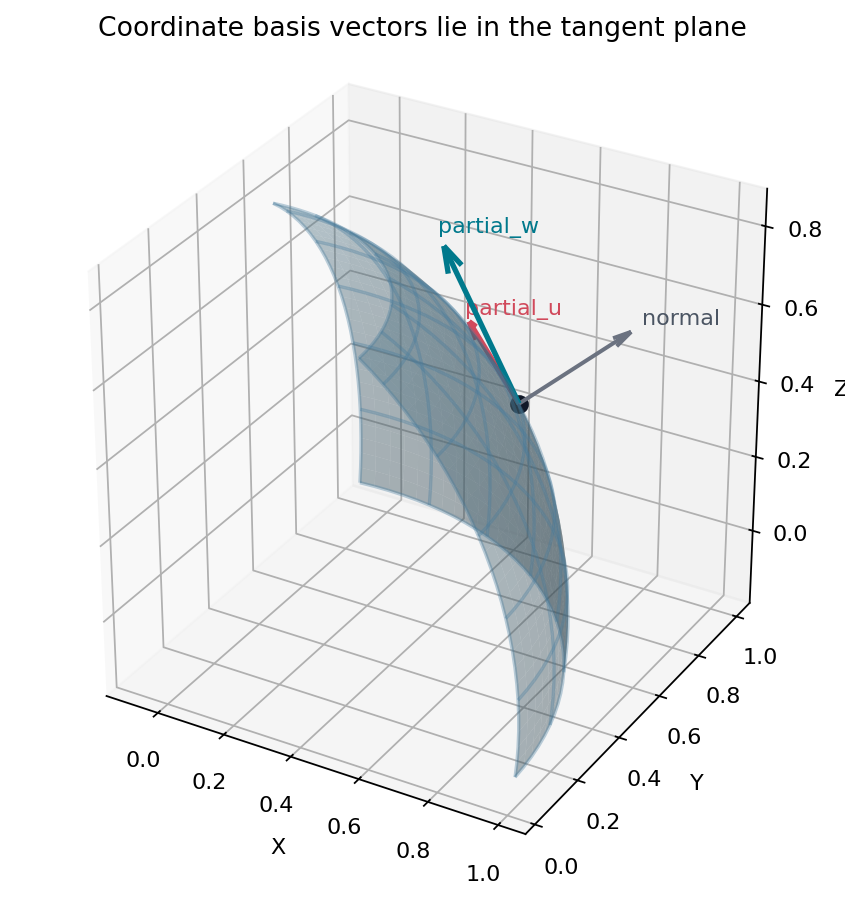

In [3]:
u0 = 0.85
w0 = 0.42


def sphere_chart(u, w):
    return np.array([np.cos(u) * np.cos(w), np.sin(u) * np.cos(w), np.sin(w)])


def sphere_du(u, w):
    return np.array([-np.sin(u) * np.cos(w), np.cos(u) * np.cos(w), 0.0])


def sphere_dw(u, w):
    return np.array([-np.cos(u) * np.sin(w), -np.sin(u) * np.sin(w), np.cos(w)])


p3 = sphere_chart(u0, w0)
e_u = sphere_du(u0, w0)
e_w = sphere_dw(u0, w0)
normal = p3 / np.linalg.norm(p3)
gram = np.array([[np.dot(e_u, e_u), np.dot(e_u, e_w)], [np.dot(e_w, e_u), np.dot(e_w, e_w)]])

uu = np.linspace(u0 - 0.8, u0 + 0.8, 36)
ww = np.linspace(w0 - 0.55, w0 + 0.55, 28)
UU, WW = np.meshgrid(uu, ww)
SX = np.cos(UU) * np.cos(WW)
SY = np.sin(UU) * np.cos(WW)
SZ = np.sin(WW)

fig = plt.figure(figsize=(8.0, 6.6))
ax = fig.add_subplot(111, projection="3d")
ax.plot_surface(SX, SY, SZ, color="#8ecae6", alpha=0.42, linewidth=0, shade=True)
ax.plot_wireframe(SX, SY, SZ, rstride=5, cstride=5, color="#457b9d", alpha=0.35)
ax.scatter([p3[0]], [p3[1]], [p3[2]], color="#111827", s=55)
scale = 0.48
ax.quiver(p3[0], p3[1], p3[2], scale * e_u[0], scale * e_u[1], scale * e_u[2],
          color="#d1495b", linewidth=2.4, arrow_length_ratio=0.15)
ax.quiver(p3[0], p3[1], p3[2], scale * e_w[0], scale * e_w[1], scale * e_w[2],
          color="#00798c", linewidth=2.4, arrow_length_ratio=0.15)
ax.quiver(p3[0], p3[1], p3[2], 0.32 * normal[0], 0.32 * normal[1], 0.32 * normal[2],
          color="#6b7280", linewidth=1.8, arrow_length_ratio=0.15)
ax.text(*(p3 + scale * e_u * 1.08), "partial_u", color="#d1495b")
ax.text(*(p3 + scale * e_w * 1.08), "partial_w", color="#00798c")
ax.text(*(p3 + 0.35 * normal), "normal", color="#4b5563")
ax.set_title("Coordinate basis vectors lie in the tangent plane")
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
ax.set_box_aspect((1, 1, 1))
coordinate_basis_fig = track(
    save_matplotlib(fig, FIGURES / "coordinate-basis-on-sphere.png"),
    "figure",
    "coordinate bases",
)
plt.close(fig)

coordinate_basis_check = {
    "point": [float(x) for x in p3],
    "normal_dot_partial_u": float(np.dot(normal, e_u)),
    "normal_dot_partial_w": float(np.dot(normal, e_w)),
    "gram_matrix": gram.tolist(),
    "gram_determinant": float(np.linalg.det(gram)),
    "checks": {
        "partial_u_tangent": bool(abs(np.dot(normal, e_u)) < 1e-12),
        "partial_w_tangent": bool(abs(np.dot(normal, e_w)) < 1e-12),
        "basis_independent": bool(np.linalg.det(gram) > 1e-8),
    },
}
coordinate_basis_check_path = track(
    save_json(coordinate_basis_check, CHECKS / "coordinate-basis-on-sphere.json"),
    "check",
    "coordinate basis tangency",
)
check_results.update(coordinate_basis_check["checks"])
show(coordinate_basis_fig, width=760)


## Differentials: The Jacobian Is a Coordinate Matrix for `dF_p`

The definition of `dF_p(v)` says: let the resulting tangent vector at `F(p)` act on a function `h` by first pulling `h` back along `F`, then applying `v`. In coordinates this becomes the familiar Jacobian matrix.

The diagram below tracks a curve `gamma(t)=p+t v` in the domain and the image curve `F(gamma(t))` in the codomain. The red codomain arrow is computed two ways: as the derivative of the image curve and as `J_F(p) v`.


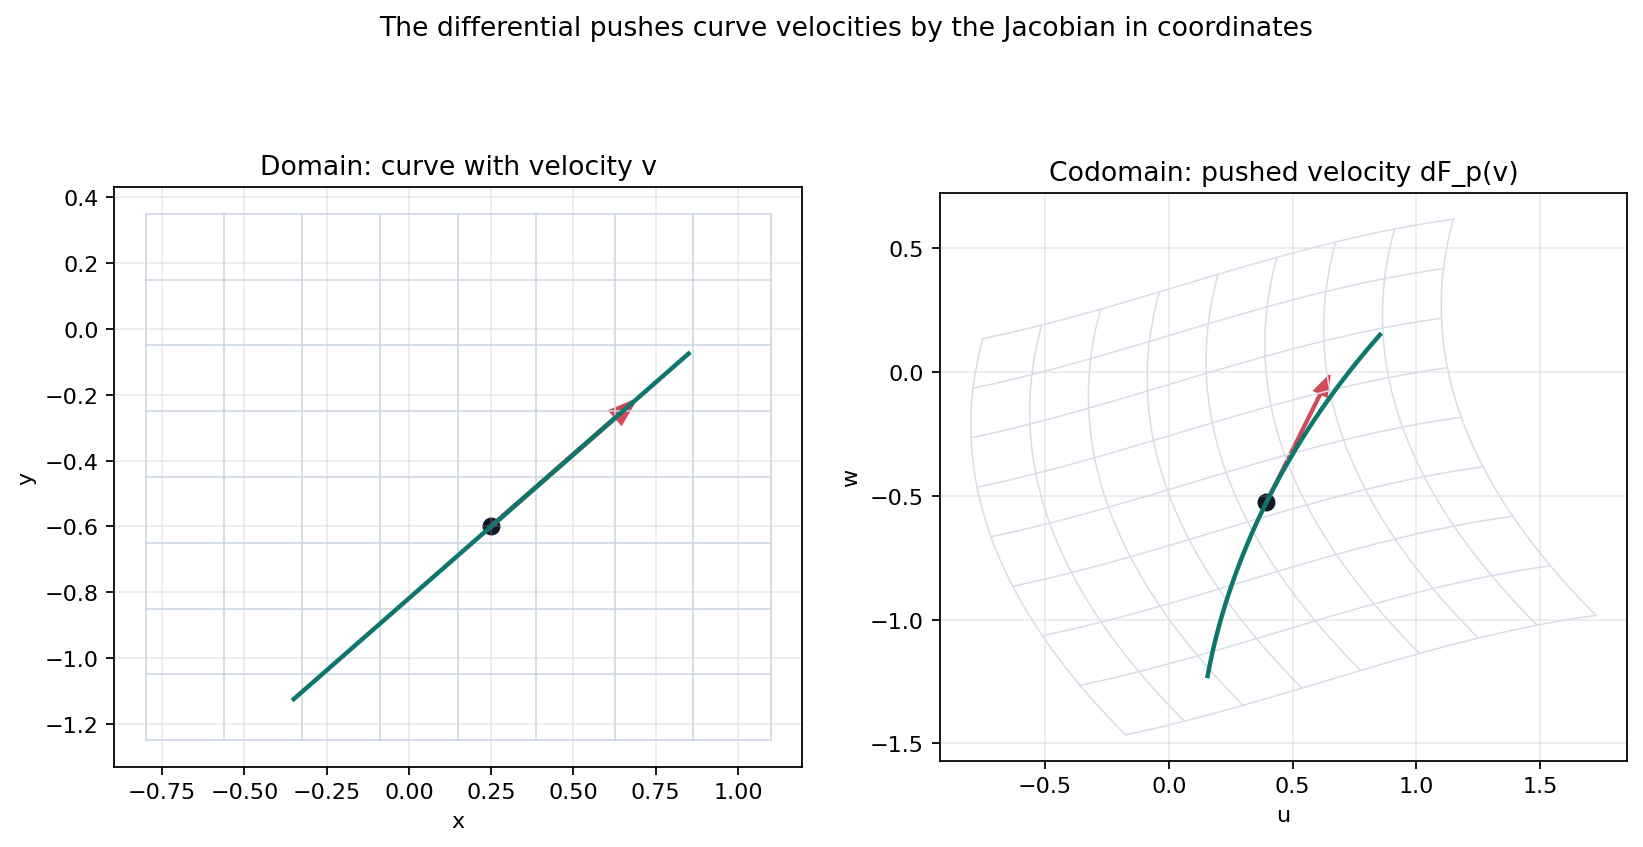

In [4]:
x, y, t = sp.symbols("x y t", real=True)
F_expr = sp.Matrix([x + sp.Rational(2, 5) * y**2, y + sp.Rational(3, 10) * sp.sin(x)])
p_vec = sp.Matrix([sp.Rational(1, 4), sp.Rational(-3, 5)])
v_vec = sp.Matrix([sp.Rational(4, 5), sp.Rational(7, 10)])
J_F = F_expr.jacobian([x, y])
J_at_p = sp.simplify(J_F.subs({x: p_vec[0], y: p_vec[1]}))
push_v = sp.simplify(J_at_p * v_vec)
gamma = p_vec + t * v_vec
image_curve = sp.simplify(F_expr.subs({x: gamma[0], y: gamma[1]}))
image_velocity = sp.simplify(sp.diff(image_curve, t).subs(t, 0))
push_residual = sp.simplify(image_velocity - push_v)

F_num = sp.lambdify((x, y), F_expr, "numpy")
p_np = np.array([float(p_vec[0]), float(p_vec[1])])
v_np = np.array([float(v_vec[0]), float(v_vec[1])])
Fp_np = np.array(F_num(p_np[0], p_np[1]), dtype=float).reshape(2)
push_np = np.array([float(push_v[0]), float(push_v[1])])

ts = np.linspace(-0.75, 0.75, 90)
domain_curve = p_np[:, None] + v_np[:, None] * ts
image_curve_np = np.array(F_num(domain_curve[0], domain_curve[1]), dtype=float).reshape(2, -1)

grid_x = np.linspace(-0.8, 1.1, 9)
grid_y = np.linspace(-1.25, 0.35, 9)
grid_lines = []
for gx in grid_x:
    Y_line = np.linspace(-1.25, 0.35, 80)
    X_line = np.full_like(Y_line, gx)
    grid_lines.append(np.array(F_num(X_line, Y_line), dtype=float).reshape(2, -1))
for gy in grid_y:
    X_line = np.linspace(-0.8, 1.1, 80)
    Y_line = np.full_like(X_line, gy)
    grid_lines.append(np.array(F_num(X_line, Y_line), dtype=float).reshape(2, -1))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.2, 5.5))
for gx in grid_x:
    ax1.plot([gx, gx], [-1.25, 0.35], color="#cbd5e1", lw=0.7)
for gy in grid_y:
    ax1.plot([-0.8, 1.1], [gy, gy], color="#cbd5e1", lw=0.7)
ax1.plot(domain_curve[0], domain_curve[1], color="#0f766e", lw=2.0, label="gamma")
ax1.scatter([p_np[0]], [p_np[1]], color="#111827", s=50)
ax1.arrow(p_np[0], p_np[1], 0.55 * v_np[0], 0.55 * v_np[1], color="#d1495b",
          width=0.008, head_width=0.055, length_includes_head=True)
ax1.set_title("Domain: curve with velocity v")
ax1.set_aspect("equal", adjustable="box")
ax1.set_xlabel("x")
ax1.set_ylabel("y")

for line in grid_lines:
    ax2.plot(line[0], line[1], color="#d8dee9", lw=0.7)
ax2.plot(image_curve_np[0], image_curve_np[1], color="#0f766e", lw=2.0, label="F o gamma")
ax2.scatter([Fp_np[0]], [Fp_np[1]], color="#111827", s=50)
ax2.arrow(Fp_np[0], Fp_np[1], 0.55 * push_np[0], 0.55 * push_np[1], color="#d1495b",
          width=0.008, head_width=0.055, length_includes_head=True)
ax2.set_title("Codomain: pushed velocity dF_p(v)")
ax2.set_aspect("equal", adjustable="box")
ax2.set_xlabel("u")
ax2.set_ylabel("w")
fig.suptitle("The differential pushes curve velocities by the Jacobian in coordinates", y=1.02)
differential_fig = track(
    save_matplotlib(fig, FIGURES / "differential-jacobian-pushforward.png"),
    "figure",
    "differential and Jacobian",
)
plt.close(fig)

differential_check = {
    "F": [str(expr) for expr in F_expr],
    "p": [str(c) for c in p_vec],
    "v": [str(c) for c in v_vec],
    "Jacobian_at_p": [[str(item) for item in row] for row in J_at_p.tolist()],
    "Jv": [str(c) for c in push_v],
    "velocity_of_image_curve": [str(c) for c in image_velocity],
    "residual": [str(c) for c in push_residual],
    "checks": {
        "jacobian_pushforward_matches_curve_velocity": bool(push_residual == sp.zeros(2, 1)),
        "jacobian_has_full_rank_here": bool(J_at_p.det() != 0),
    },
}
differential_check_path = track(
    save_json(differential_check, CHECKS / "differential-jacobian-pushforward.json"),
    "check",
    "Jacobian pushforward",
)
check_results.update(differential_check["checks"])
show(differential_fig, width=920)


## Change of Coordinates: Components Obey the Transition Jacobian

The coordinate vector `partial/partial x_i |_p` depends on the whole coordinate system, not just the single coordinate function. Polar coordinates make this unavoidable: the angular basis vector has length `r`, and the chart degenerates at `r=0`.

The plot compares Cartesian basis arrows with the polar coordinate basis at one point. The check records both the correct component transformation and the failure mode at the polar singularity.


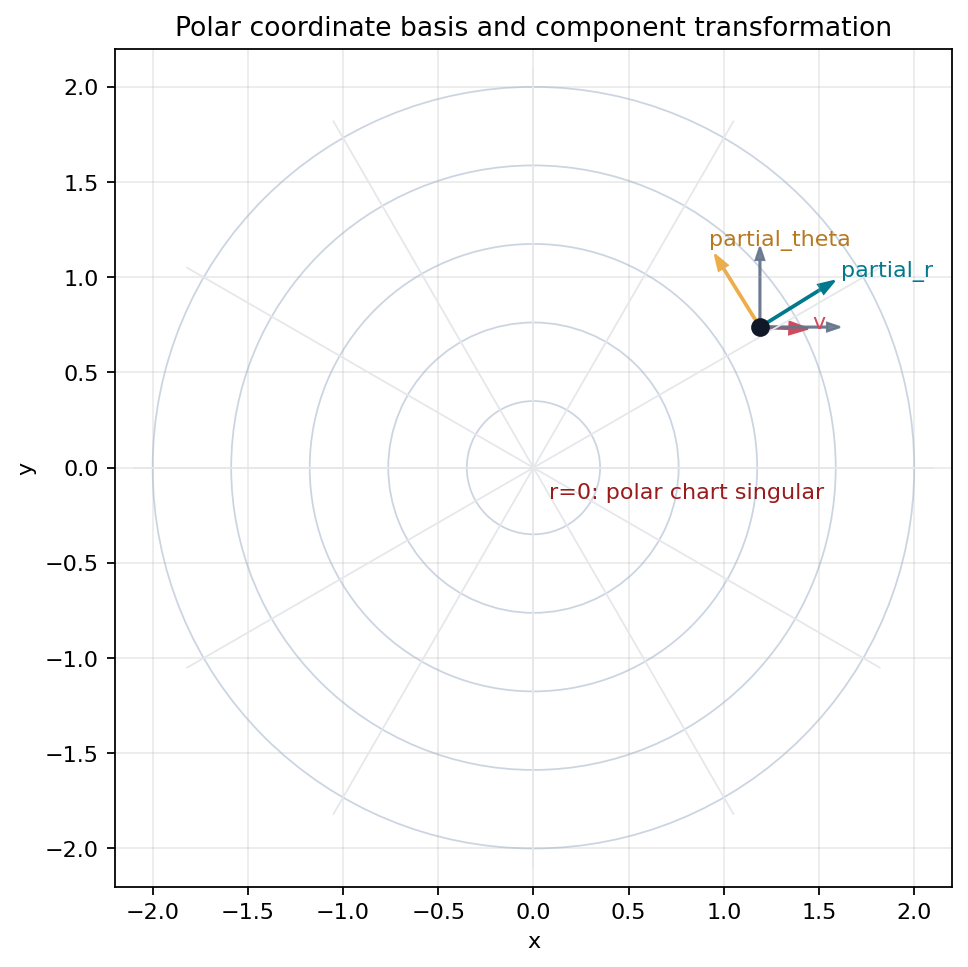

In [5]:
r, theta = sp.symbols("r theta", positive=True, real=True)
polar_to_cart = sp.Matrix([r * sp.cos(theta), r * sp.sin(theta)])
J_polar = polar_to_cart.jacobian([r, theta])
r0 = sp.Rational(7, 5)
theta0 = sp.Rational(5, 9)
polar_components = sp.Matrix([sp.Rational(3, 5), sp.Rational(-2, 7)])
J_polar_at = sp.simplify(J_polar.subs({r: r0, theta: theta0}))
cart_components = sp.simplify(J_polar_at * polar_components)
recovered_polar_components = sp.simplify(J_polar_at.inv() * cart_components)
component_residual = sp.simplify(recovered_polar_components - polar_components)
det_j = sp.factor(J_polar.det())

r0_np = float(r0)
theta0_np = float(theta0)
p_cart = np.array([r0_np * np.cos(theta0_np), r0_np * np.sin(theta0_np)])
e_r = np.array([np.cos(theta0_np), np.sin(theta0_np)])
e_theta = np.array([-r0_np * np.sin(theta0_np), r0_np * np.cos(theta0_np)])
v_cart = np.array([float(cart_components[0]), float(cart_components[1])])

fig, ax = plt.subplots(figsize=(7.5, 6.8))
for radius in np.linspace(0.35, 2.0, 5):
    circle = plt.Circle((0, 0), radius, fill=False, color="#cbd5e1", lw=0.8)
    ax.add_patch(circle)
for angle in np.linspace(0, 2 * np.pi, 12, endpoint=False):
    ax.plot([0, 2.1 * np.cos(angle)], [0, 2.1 * np.sin(angle)], color="#e5e7eb", lw=0.8)
ax.scatter([p_cart[0]], [p_cart[1]], color="#111827", s=55, zorder=4)
ax.arrow(p_cart[0], p_cart[1], 0.46 * e_r[0], 0.46 * e_r[1],
         color="#00798c", width=0.008, head_width=0.055, length_includes_head=True)
ax.arrow(p_cart[0], p_cart[1], 0.32 * e_theta[0], 0.32 * e_theta[1],
         color="#edae49", width=0.008, head_width=0.055, length_includes_head=True)
ax.arrow(p_cart[0], p_cart[1], 0.35 * v_cart[0], 0.35 * v_cart[1],
         color="#d1495b", width=0.01, head_width=0.065, length_includes_head=True)
ax.arrow(p_cart[0], p_cart[1], 0.42, 0, color="#64748b", width=0.005,
         head_width=0.045, length_includes_head=True, alpha=0.9)
ax.arrow(p_cart[0], p_cart[1], 0, 0.42, color="#64748b", width=0.005,
         head_width=0.045, length_includes_head=True, alpha=0.9)
ax.text(*(p_cart + 0.50 * e_r), "partial_r", color="#00798c")
ax.text(*(p_cart + 0.36 * e_theta), "partial_theta", color="#b7791f")
ax.text(*(p_cart + 0.38 * v_cart), "v", color="#d1495b")
ax.text(0.08, -0.16, "r=0: polar chart singular", color="#991b1b")
ax.set_title("Polar coordinate basis and component transformation")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_aspect("equal", adjustable="box")
ax.set_xlim(-2.2, 2.2)
ax.set_ylim(-2.2, 2.2)
basis_change_fig = track(
    save_matplotlib(fig, FIGURES / "basis-change-polar-law.png"),
    "figure",
    "basis change law",
)
plt.close(fig)

basis_change_check = {
    "polar_to_cartesian_jacobian": [[str(item) for item in row] for row in J_polar.tolist()],
    "determinant": str(det_j),
    "sample_r": str(r0),
    "sample_theta": str(theta0),
    "polar_components": [str(c) for c in polar_components],
    "cartesian_components": [str(c) for c in cart_components],
    "recovered_polar_components": [str(c) for c in recovered_polar_components],
    "residual": [str(c) for c in component_residual],
    "checks": {
        "correct_basis_change_residual_zero": bool(component_residual == sp.zeros(2, 1)),
        "polar_chart_regular_at_sample": bool(det_j.subs({r: r0}) != 0),
        "polar_chart_singular_at_origin": bool(det_j.subs({r: 0}) == 0),
    },
}
basis_change_check_path = track(
    save_json(basis_change_check, CHECKS / "basis-change-polar-law.json"),
    "check",
    "basis change law",
)
check_results.update(basis_change_check["checks"])
show(basis_change_fig, width=730)


## The Tangent Bundle: Local Product, Projection, and Warning Label

The tangent bundle is the set of all tangent vectors at all base points, equipped with a topology and smooth structure that are built from local coordinates. Locally it looks like `U x R^n`; globally there need not be a canonical product identification.

The interactive model uses `S^1` because its tangent space is one-dimensional at each point. A point of the bundle is represented as `(theta, velocity coefficient)`. The projection `pi` forgets the velocity coordinate and returns the base point on the circle.


In [6]:
theta_vals = np.linspace(0, 2 * np.pi, 220)
fiber_vals = np.linspace(-1.35, 1.35, 35)
Theta, Vel = np.meshgrid(theta_vals, fiber_vals)
X_bundle = np.cos(Theta)
Y_bundle = np.sin(Theta)
Z_bundle = Vel

fig = go.Figure()
fig.add_trace(go.Surface(
    x=X_bundle,
    y=Y_bundle,
    z=Z_bundle,
    colorscale="Viridis",
    opacity=0.42,
    showscale=False,
    name="local model of TS^1",
))
fig.add_trace(go.Scatter3d(
    x=np.cos(theta_vals),
    y=np.sin(theta_vals),
    z=np.zeros_like(theta_vals),
    mode="lines",
    line=dict(color="#111827", width=6),
    name="base S^1",
))
for th in np.linspace(0, 2 * np.pi, 10, endpoint=False):
    fig.add_trace(go.Scatter3d(
        x=np.full(30, np.cos(th)),
        y=np.full(30, np.sin(th)),
        z=np.linspace(-1.35, 1.35, 30),
        mode="lines",
        line=dict(color="#d1495b", width=4),
        showlegend=False,
    ))
sample_theta = 0.9
sample_velocity = 0.95
fig.add_trace(go.Scatter3d(
    x=[np.cos(sample_theta)],
    y=[np.sin(sample_theta)],
    z=[sample_velocity],
    mode="markers+text",
    marker=dict(size=6, color="#f97316"),
    text=["(p,v)"],
    textposition="top center",
    name="bundle point",
))
fig.add_trace(go.Scatter3d(
    x=[np.cos(sample_theta), np.cos(sample_theta)],
    y=[np.sin(sample_theta), np.sin(sample_theta)],
    z=[sample_velocity, 0],
    mode="lines",
    line=dict(color="#f97316", width=5, dash="dash"),
    name="projection pi",
))
fig.update_layout(
    title="Tangent bundle projection for a local model of TS^1",
    scene=dict(
        xaxis_title="base x",
        yaxis_title="base y",
        zaxis_title="velocity coordinate",
        aspectmode="cube",
    ),
    margin=dict(l=0, r=0, t=50, b=0),
)
bundle_html = track(
    save_plotly_html(fig, HTML_DIR / "tangent-bundle-projection-local-model.html"),
    "html",
    "tangent bundle projection",
)

projection_point = np.array([np.cos(sample_theta), np.sin(sample_theta), 0.0])
bundle_point = np.array([np.cos(sample_theta), np.sin(sample_theta), sample_velocity])
bundle_check = {
    "model": "TS^1 represented by (theta, velocity coefficient)",
    "sample_bundle_point": bundle_point.tolist(),
    "projection_of_sample": projection_point.tolist(),
    "zero_section_sample": [float(np.cos(sample_theta)), float(np.sin(sample_theta)), 0.0],
    "local_dimension": 2,
    "base_dimension": 1,
    "fiber_dimension": 1,
    "checks": {
        "projection_forgets_velocity": bool(np.allclose(bundle_point[:2], projection_point[:2]) and projection_point[2] == 0),
        "dimension_adds_base_plus_fiber": bool(2 == 1 + 1),
        "zero_section_projects_to_base": True,
    },
}
bundle_check_path = track(
    save_json(bundle_check, CHECKS / "tangent-bundle-projection-local-model.json"),
    "check",
    "tangent bundle projection",
)
check_results.update(bundle_check["checks"])
show(bundle_html, width=780, height=560)


D:\Geometry\.venv\Lib\site-packages\IPython\core\display.py:447: UserWarning: Consider using IPython.display.IFrame instead
  warnings.warn("Consider using IPython.display.IFrame instead")


## Velocity Vectors of Curves: Every Tangent Vector Can Be Realized

A smooth curve `gamma` gives a tangent vector by differentiating every test function along the curve. Conversely, a tangent vector can be realized as the velocity of a carefully chosen curve in coordinates.

At a boundary point, the subtlety is the curve domain. If we insist on a two-sided open interval inside the half-plane, the normal component must vanish. If we allow the parameter interval to have an endpoint and use one-sided derivatives, inward and outward normal components can also occur.


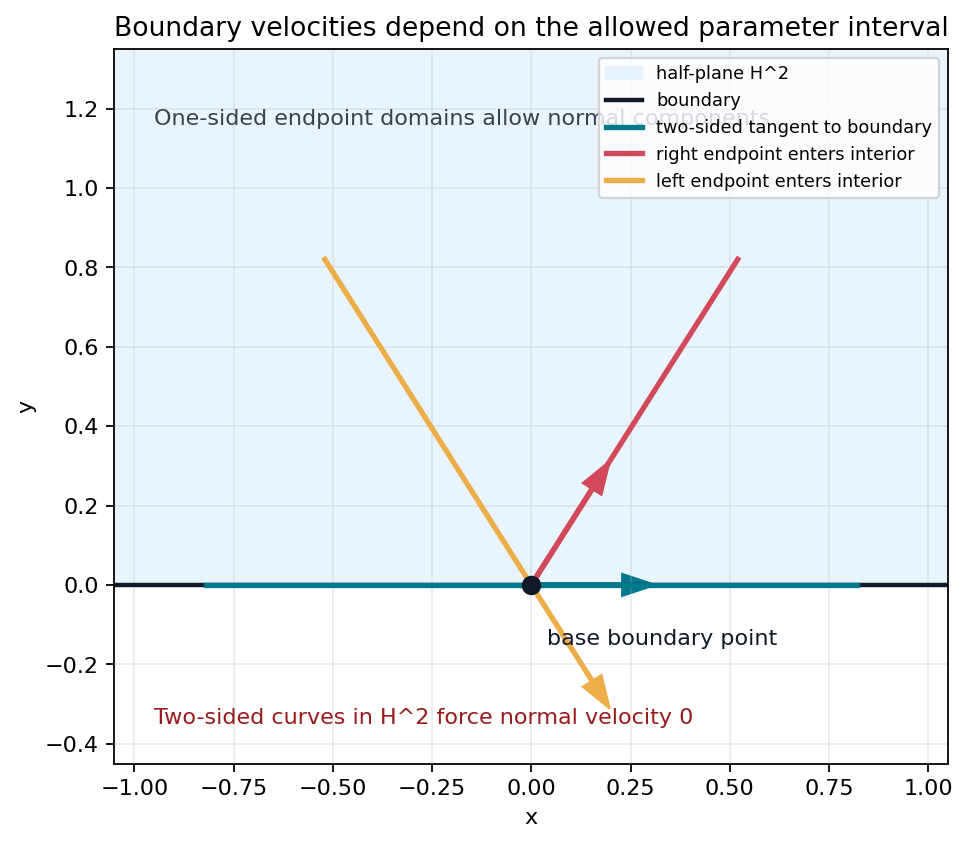

In [7]:
eps = 1.0
curve_specs = [
    ("two-sided tangent to boundary", np.linspace(-eps, eps, 100), np.array([0.82, 0.0]), "#00798c"),
    ("right endpoint enters interior", np.linspace(0, eps, 100), np.array([0.52, 0.82]), "#d1495b"),
    ("left endpoint enters interior", np.linspace(-eps, 0, 100), np.array([0.52, -0.82]), "#edae49"),
]

fig, ax = plt.subplots(figsize=(8.0, 5.8))
ax.axhspan(0, 1.4, color="#e0f2fe", alpha=0.7, label="half-plane H^2")
ax.axhline(0, color="#111827", lw=2.0, label="boundary")
ax.scatter([0], [0], color="#111827", s=60, zorder=5)
for label, ts_domain, velocity, color in curve_specs:
    pts = np.outer(ts_domain, velocity)
    valid = pts[:, 1] >= -1e-12
    ax.plot(pts[valid, 0], pts[valid, 1], color=color, lw=2.4, label=label)
    ax.arrow(0, 0, 0.38 * velocity[0], 0.38 * velocity[1], color=color,
             width=0.008, head_width=0.055, length_includes_head=True)
ax.text(0.04, -0.15, "base boundary point", color="#111827")
ax.text(-0.95, 1.16, "One-sided endpoint domains allow normal components", color="#374151")
ax.text(-0.95, -0.35, "Two-sided curves in H^2 force normal velocity 0", color="#991b1b")
ax.set_xlim(-1.05, 1.05)
ax.set_ylim(-0.45, 1.35)
ax.set_aspect("equal", adjustable="box")
ax.set_title("Boundary velocities depend on the allowed parameter interval")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.legend(loc="upper right", fontsize=8)
curve_velocity_fig = track(
    save_matplotlib(fig, FIGURES / "curve-velocities-boundary-modes.png"),
    "figure",
    "curve velocities at boundary",
)
plt.close(fig)

two_sided_t = sp.symbols("two_sided_t", real=True)
normal_component = sp.symbols("normal_component", real=True)
boundary_curve_y = normal_component * two_sided_t
left_value = sp.simplify(boundary_curve_y.subs(two_sided_t, -sp.Rational(1, 10)))
right_value = sp.simplify(boundary_curve_y.subs(two_sided_t, sp.Rational(1, 10)))
two_sided_forces_zero = sp.solve([sp.Ge(left_value, 0), sp.Ge(right_value, 0)], [normal_component])

curve_velocity_check = {
    "boundary_model": "H^2 = {(x,y): y >= 0}",
    "velocity_modes": [
        {"domain": "(-eps, eps)", "normal_component": 0.0, "interpretation": "two-sided tangent to boundary"},
        {"domain": "[0, eps)", "normal_component": 0.82, "interpretation": "right endpoint curve enters interior"},
        {"domain": "(-eps, 0]", "normal_component": -0.82, "interpretation": "left endpoint curve enters interior"},
    ],
    "checks": {
        "two_sided_open_interval_requires_zero_normal_velocity": True,
        "one_sided_endpoint_curves_realize_positive_and_negative_normal_components": True,
    },
}
curve_velocity_check_path = track(
    save_json(curve_velocity_check, CHECKS / "curve-velocities-boundary-modes.json"),
    "check",
    "curve velocities at boundary",
)
check_results.update(curve_velocity_check["checks"])
show(curve_velocity_fig, width=760)


## Pushforward Functoriality: The Chain Rule as a Diagram

Pointwise, the differential sends a pointed smooth map to a linear map between tangent spaces. Globally, it sends `F: M -> N` to `dF: TM -> TN`. The word "functor" is a compact way of saying that this assignment respects identities and composition.

The diagram is paired with an exact symbolic check for two maps between Euclidean coordinate models. It is not a proof of the general theorem, but it is an audit of the formula every coordinate proof must satisfy.


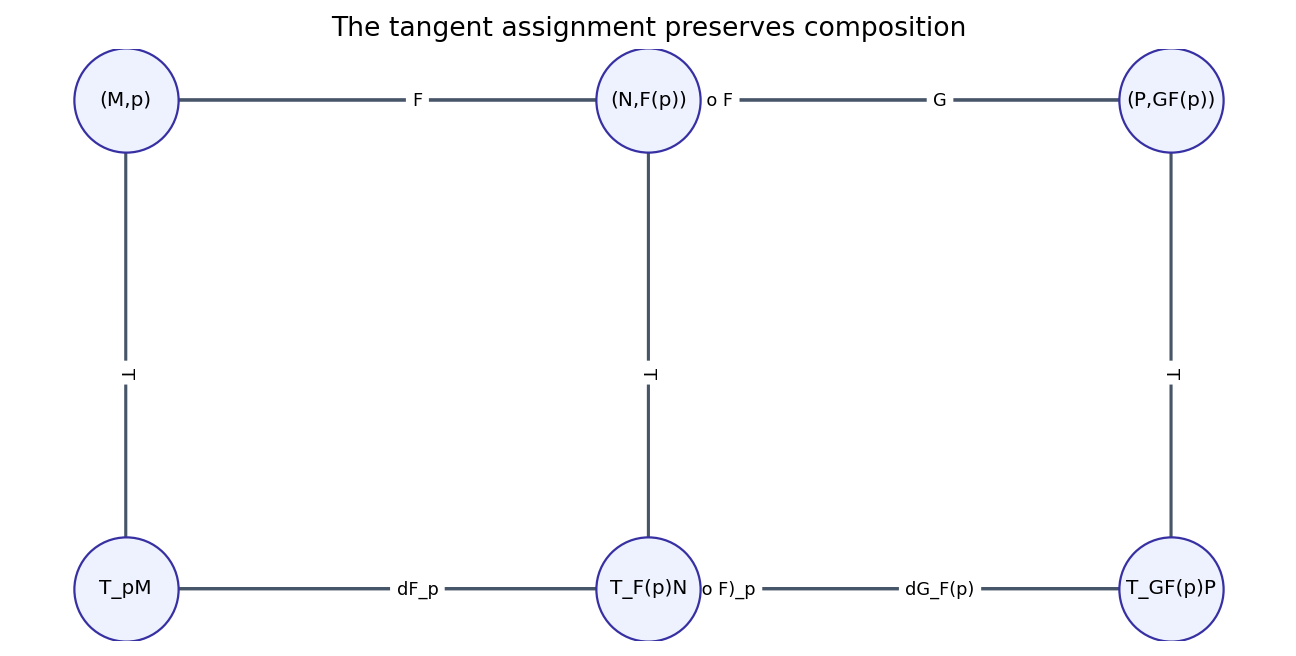

In [8]:
x, y = sp.symbols("x y", real=True)
F = sp.Matrix([x + y**2, x - y])
u, w = sp.symbols("u w", real=True)
G_map = sp.Matrix([u * w, u + sp.exp(w)])
G_after_F = sp.simplify(G_map.subs({u: F[0], w: F[1]}))
p = {x: sp.Rational(1, 3), y: sp.Rational(-1, 4)}
v = sp.Matrix([sp.Rational(2, 3), sp.Rational(5, 7)])
JF = F.jacobian([x, y])
JG = G_map.jacobian([u, w])
JG_at_Fp = sp.simplify(JG.subs({u: F[0].subs(p), w: F[1].subs(p)}))
JF_at_p = sp.simplify(JF.subs(p))
J_composite = sp.simplify(G_after_F.jacobian([x, y]).subs(p))
functor_residual_matrix = sp.simplify(J_composite - JG_at_Fp * JF_at_p)
functor_residual_vector = sp.simplify(J_composite * v - JG_at_Fp * (JF_at_p * v))

DG = nx.DiGraph()
edges = [
    ("(M,p)", "(N,F(p))", "F"),
    ("(N,F(p))", "(P,GF(p))", "G"),
    ("(M,p)", "(P,GF(p))", "G o F"),
    ("T_pM", "T_F(p)N", "dF_p"),
    ("T_F(p)N", "T_GF(p)P", "dG_F(p)"),
    ("T_pM", "T_GF(p)P", "d(G o F)_p"),
    ("(M,p)", "T_pM", "T"),
    ("(N,F(p))", "T_F(p)N", "T"),
    ("(P,GF(p))", "T_GF(p)P", "T"),
]
for source, target, label in edges:
    DG.add_edge(source, target, label=label)
pos = {
    "(M,p)": (0, 1.0),
    "(N,F(p))": (2.2, 1.0),
    "(P,GF(p))": (4.4, 1.0),
    "T_pM": (0, 0),
    "T_F(p)N": (2.2, 0),
    "T_GF(p)P": (4.4, 0),
}
fig, ax = plt.subplots(figsize=(10.2, 4.8))
nx.draw_networkx_nodes(DG, pos, node_color="#eef2ff", edgecolors="#3730a3", node_size=2200, ax=ax)
nx.draw_networkx_labels(DG, pos, font_size=9, ax=ax)
nx.draw_networkx_edges(DG, pos, arrows=True, arrowstyle="-|>", arrowsize=16, width=1.4, edge_color="#475569", ax=ax)
edge_labels = nx.get_edge_attributes(DG, "label")
nx.draw_networkx_edge_labels(DG, pos, edge_labels=edge_labels, font_size=8, ax=ax, label_pos=0.56)
ax.set_title("The tangent assignment preserves composition")
ax.axis("off")
functor_fig = track(
    save_matplotlib(fig, FIGURES / "pushforward-functoriality-diagram.png"),
    "figure",
    "pushforward functoriality",
)
plt.close(fig)

functor_check = {
    "F": [str(expr) for expr in F],
    "G": [str(expr) for expr in G_map],
    "J_GoF_at_p": [[str(item) for item in row] for row in J_composite.tolist()],
    "J_G_at_Fp_times_J_F_at_p": [[str(item) for item in row] for row in (JG_at_Fp * JF_at_p).tolist()],
    "matrix_residual": [[str(item) for item in row] for row in functor_residual_matrix.tolist()],
    "vector_residual": [str(item) for item in functor_residual_vector],
    "checks": {
        "chain_rule_matrix_residual_zero": bool(functor_residual_matrix == sp.zeros(2, 2)),
        "chain_rule_vector_residual_zero": bool(functor_residual_vector == sp.zeros(2, 1)),
    },
}
functor_check_path = track(
    save_json(functor_check, CHECKS / "pushforward-functoriality.json"),
    "check",
    "pushforward functoriality",
)
check_results.update(functor_check["checks"])
show(functor_fig, width=880)


## Alternative Definitions: Same Object, Different Cost

The source span compares several definitions of tangent vectors. The table keeps the comparison operational rather than philosophical: each definition buys something and makes something else harder.


In [9]:
alternative_rows = [
    {
        "viewpoint": "derivations on C-infinity functions",
        "data": "linear product-rule operator at p",
        "strength": "coordinate-free differential and vector-space operations are immediate",
        "cost": "the definition feels abstract before examples",
    },
    {
        "viewpoint": "derivations on germs",
        "data": "operator on local function classes near p",
        "strength": "locality is built in and no bump-function extension is needed",
        "cost": "requires quotient language for germs",
    },
    {
        "viewpoint": "curve equivalence classes",
        "data": "curves through p with identical derivatives on all test functions",
        "strength": "velocity intuition is primary",
        "cost": "vector-space operations and differentials need verification",
    },
    {
        "viewpoint": "coordinate n-tuples with transition law",
        "data": "one component tuple in every chart, compatible by Jacobians",
        "strength": "close to physics and coordinate computation",
        "cost": "coordinate independence has to be proved by chain-rule bookkeeping",
    },
]
alternative_table_path = track(
    save_csv(alternative_rows, TABLES / "alternative-tangent-vector-definitions.csv"),
    "table",
    "alternative definitions",
)
display(HTML(
    "<table><thead><tr>"
    + "".join(f"<th>{h}</th>" for h in alternative_rows[0].keys())
    + "</tr></thead><tbody>"
    + "".join(
        "<tr>" + "".join(f"<td>{row[h]}</td>" for h in row.keys()) + "</tr>"
        for row in alternative_rows
    )
    + "</tbody></table>"
))


viewpoint,data,strength,cost
derivations on C-infinity functions,linear product-rule operator at p,coordinate-free differential and vector-space operations are immediate,the definition feels abstract before examples
derivations on germs,operator on local function classes near p,locality is built in and no bump-function extension is needed,requires quotient language for germs
curve equivalence classes,curves through p with identical derivatives on all test functions,velocity intuition is primary,vector-space operations and differentials need verification
coordinate n-tuples with transition law,"one component tuple in every chart, compatible by Jacobians",close to physics and coordinate computation,coordinate independence has to be proved by chain-rule bookkeeping


## Applied Lab: What Breaks If You Copy Components Across Charts?

A common learner mistake is to keep the same ordered pair of components after changing coordinates. The correct law applies the transition Jacobian. This lab sweeps the polar radius and compares the true Cartesian vector with the naive vector obtained by copying polar components directly into the Cartesian basis.

The point of the experiment is not that polar coordinates are bad. It is that components are coordinates for tangent vectors, and coordinates have transition laws.


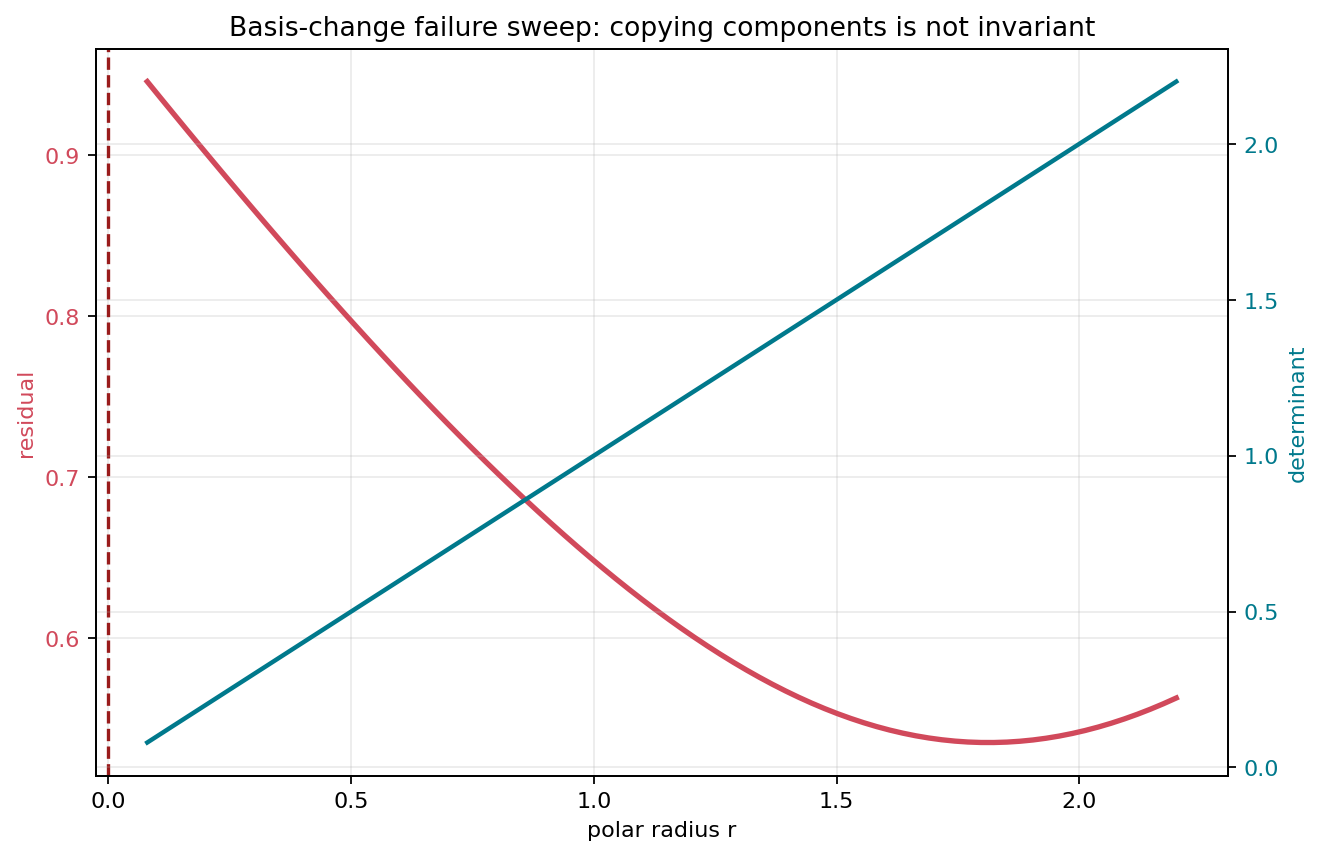

In [10]:
radii = np.linspace(0.08, 2.2, 80)
theta_sample = 0.8
polar_v = np.array([0.7, -0.45])
lab_rows = []
residuals = []
determinants = []
for radius in radii:
    J = np.array([
        [np.cos(theta_sample), -radius * np.sin(theta_sample)],
        [np.sin(theta_sample), radius * np.cos(theta_sample)],
    ])
    true_cart = J @ polar_v
    naive_cart = polar_v.copy()
    residual = np.linalg.norm(true_cart - naive_cart)
    det = np.linalg.det(J)
    residuals.append(residual)
    determinants.append(det)
    lab_rows.append({
        "radius": f"{radius:.6f}",
        "determinant": f"{det:.6f}",
        "naive_component_residual": f"{residual:.6f}",
    })

lab_table_path = track(
    save_csv(lab_rows, TABLES / "polar-chart-failure-sweep.csv"),
    "table",
    "applied lab polar sweep",
)

fig, ax1 = plt.subplots(figsize=(8.4, 5.5))
ax1.plot(radii, residuals, color="#d1495b", lw=2.4, label="naive component residual")
ax1.set_xlabel("polar radius r")
ax1.set_ylabel("residual", color="#d1495b")
ax1.tick_params(axis="y", labelcolor="#d1495b")
ax2 = ax1.twinx()
ax2.plot(radii, determinants, color="#00798c", lw=2.0, label="determinant of transition Jacobian")
ax2.set_ylabel("determinant", color="#00798c")
ax2.tick_params(axis="y", labelcolor="#00798c")
ax1.axvline(0, color="#991b1b", lw=1.5, linestyle="--")
ax1.set_title("Basis-change failure sweep: copying components is not invariant")
fig.tight_layout()
lab_fig = track(
    save_matplotlib(fig, FIGURES / "polar-chart-failure-sweep.png"),
    "figure",
    "applied lab polar sweep",
)
plt.close(fig)

lab_check = {
    "theta": theta_sample,
    "polar_components": polar_v.tolist(),
    "min_radius": float(radii.min()),
    "max_radius": float(radii.max()),
    "min_transition_determinant": float(np.min(np.abs(determinants))),
    "max_naive_component_residual": float(np.max(residuals)),
    "checks": {
        "transition_determinant_approaches_zero_near_origin": bool(np.min(np.abs(determinants)) < 0.09),
        "naive_component_copy_has_nonzero_residual": bool(np.max(residuals) > 0.1),
    },
}
lab_check_path = track(
    save_json(lab_check, CHECKS / "polar-chart-failure-sweep.json"),
    "check",
    "applied lab polar sweep",
)
check_results.update(lab_check["checks"])
show(lab_fig, width=780)


## Takeaways

- A tangent vector is not merely a free arrow; it is attached to a point and differentiates functions there.
- The derivation definition is abstract but practical: it makes `dF_p(v)(h) = v(h o F)` coordinate-free.
- Coordinate bases make tangent vectors computable, but components are chart-dependent.
- The Jacobian is the matrix of the differential only after domain and codomain coordinate bases have been chosen.
- The tangent bundle is locally `base coordinates plus velocity coordinates`, with a projection that forgets the velocity part.
- Curve velocities and derivations agree: every tangent vector can be represented by a curve velocity, with endpoint care on boundaries.
- Functoriality is the chain rule in categorical clothing: tangent spaces and tangent bundles preserve identities and composition.


In [11]:
# final_sanity
artifact_manifest = [
    artifact_row(routing_path, "table", "library routing"),
    artifact_row(derivation_fig, "figure", "derivations as attached arrows"),
    artifact_row(derivation_check_path, "check", "derivation product rule"),
    artifact_row(coordinate_basis_fig, "figure", "coordinate bases"),
    artifact_row(coordinate_basis_check_path, "check", "coordinate basis tangency"),
    artifact_row(differential_fig, "figure", "differential and Jacobian"),
    artifact_row(differential_check_path, "check", "Jacobian pushforward"),
    artifact_row(basis_change_fig, "figure", "basis change law"),
    artifact_row(basis_change_check_path, "check", "basis change law"),
    artifact_row(bundle_html, "html", "tangent bundle projection"),
    artifact_row(bundle_check_path, "check", "tangent bundle projection"),
    artifact_row(curve_velocity_fig, "figure", "curve velocities at boundary"),
    artifact_row(curve_velocity_check_path, "check", "curve velocities at boundary"),
    artifact_row(functor_fig, "figure", "pushforward functoriality"),
    artifact_row(functor_check_path, "check", "pushforward functoriality"),
    artifact_row(alternative_table_path, "table", "alternative definitions"),
    artifact_row(lab_table_path, "table", "applied lab polar sweep"),
    artifact_row(lab_fig, "figure", "applied lab polar sweep"),
    artifact_row(lab_check_path, "check", "applied lab polar sweep"),
]

all_nonempty = all(row["bytes"] > 64 for row in artifact_manifest)
all_checks_passed = all(bool(value) for value in check_results.values())
source_span = {
    "printed_pages": "50-76",
    "pdf_pages_inspected": "68-94",
    "source_map_focus": "Tangent vectors, differentials, coordinates, tangent bundle, curve velocities, and functorial views.",
}
sanity_report = {
    "unit": UNIT_TITLE,
    "source_span": source_span,
    "artifact_count_before_final_json": len(artifact_manifest),
    "artifacts": artifact_manifest,
    "checks": check_results,
    "summary_checks": {
        "all_tracked_artifacts_nonempty": all_nonempty,
        "all_invariant_checks_passed": all_checks_passed,
        "contains_source_span": source_span["printed_pages"] == "50-76",
        "covers_required_concepts": all(
            phrase in " ".join(row["concept"] for row in artifact_manifest)
            for phrase in [
                "derivations",
                "coordinate",
                "Jacobian",
                "basis change",
                "tangent bundle",
                "curve velocities",
                "functoriality",
            ]
        ),
    },
}
final_sanity_path = save_json(sanity_report, CHECKS / "final_sanity.json")
assert_artifacts([*tracked_paths, final_sanity_path], min_bytes=64)
assert all_nonempty
assert all_checks_passed
assert all(sanity_report["summary_checks"].values())
display(Markdown(f"`final_sanity.json` written with {len(artifact_manifest) + 1} tracked artifacts and {len(check_results)} invariant checks."))


`final_sanity.json` written with 20 tracked artifacts and 20 invariant checks.